In [1]:
import os
import string
import shutil
from PIL import Image, ImageDraw, ImageFont
import matplotlib.font_manager as fm
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm
import cv2
import numpy as np
from utils import detect_boxes, font_supports_all_chars, render_char

# --- Configuration ---
output_base_dir = "rendered_fonts"
os.makedirs(output_base_dir, exist_ok=True)

# Characters to render: Uppercase, Lowercase, and Digits
characters = string.ascii_uppercase + string.ascii_lowercase + string.digits

# Rendering parameters
image_size = (128, 128)      # Image dimensions (width, height)
bg_color = (255, 255, 255) # Background color (white)
text_color = (0, 0, 0)     # Text color (black)
fixed_font_size = 120       # Fixed font size chosen to roughly fill the canvas

def save_image(img, output_path):
    """
    Save the image to disk.
    """
    img.save(output_path)
    return output_path

def main():
    # Discover system fonts
    print("Discovering system fonts")
    system_fonts = fm.findSystemFonts(fontpaths=None, fontext='ttf')
    print(f"Found {len(system_fonts)} fonts.")

    tasks = []  # Each task: (font_path, char, font_folder)
    for font_path in tqdm(system_fonts, desc="Checking and aggregating fonts"):
        if not font_supports_all_chars(font_path, characters, fixed_font_size):
            print(f"Skipping font: {font_path} (missing at least one glyph)")
            continue
        
        # Derive a font name from the file name (without extension)
        font_name = os.path.splitext(os.path.basename(font_path))[0]
        font_folder = os.path.join(output_base_dir, font_name)
        os.makedirs(font_folder, exist_ok=True)
        
        for char in characters:
            tasks.append((font_path, char, font_folder))

    # Use ThreadPoolExecutor for asynchronous image saving
    save_futures = []
    with ThreadPoolExecutor() as executor:
        # Process each task sequentially for rendering,
        # and schedule saving asynchronously.
        for font_path, char, font_folder in tqdm(tasks, desc="Rendering fonts"):
            task = (font_path, char, font_folder, image_size, bg_color, text_color, fixed_font_size)
            img, output_path = render_char(task)
            if img is not None:
                future = executor.submit(save_image, img, output_path)
                save_futures.append(future)
        
        # Wait for all save operations to complete
        for future in tqdm(as_completed(save_futures), total=len(save_futures), desc="Saving images"):
            _ = future.result()
    
    print("Rendering complete!")

    # Remove folders that do not have all characters
    for font_folder in os.listdir(output_base_dir):
        folder_path = os.path.join(output_base_dir, font_folder)
        if os.path.isdir(folder_path):
            num_files = len(os.listdir(folder_path))
            if num_files < len(characters):
                shutil.rmtree(folder_path)

if __name__ == '__main__':
    main()


Discovering system fonts


In [10]:
path = "/Users/ethan.smith/fonts/rendered_fonts/Apple Braille Outline 6 Dot/digit_2.png"
img = Image.open(path).resize((128,128), Image.Resampling.NEAREST)
detect_boxes(img, debug=True)


FileNotFoundError: [Errno 2] No such file or directory: '/Users/ethan.smith/fonts/rendered_fonts/Apple Braille Outline 6 Dot/digit_2.png'

glyph_A_wght_300.png
Saved image with value=300.0 as glyph_A_wght_300.png.
glyph_A_wght_400.png
Saved image with value=400.0 as glyph_A_wght_400.png.
glyph_A_wght_500.png
Saved image with value=500.0 as glyph_A_wght_500.png.
glyph_A_wght_600.png
Saved image with value=600.0 as glyph_A_wght_600.png.
glyph_A_wght_700.png
Saved image with value=700.0 as glyph_A_wght_700.png.
glyph_A_wght_800.png
Saved image with value=800.0 as glyph_A_wght_800.png.


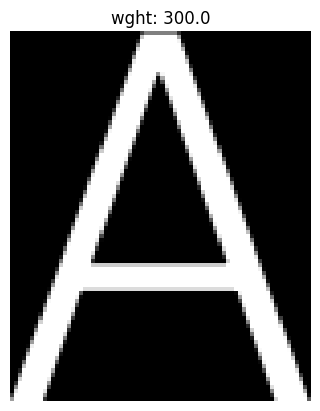

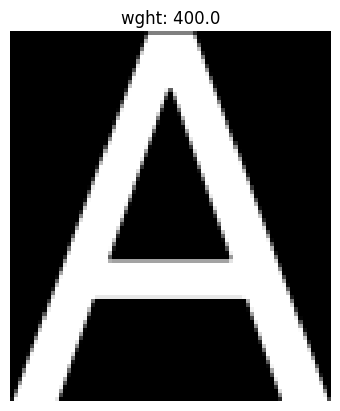

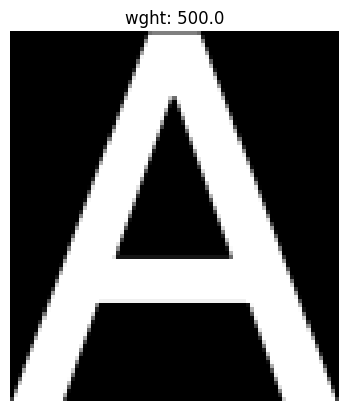

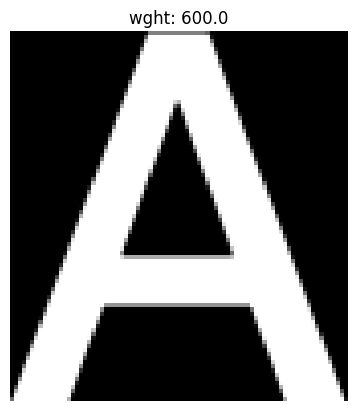

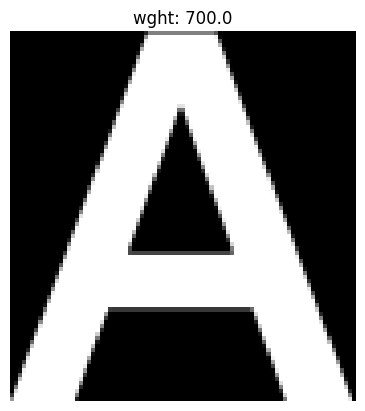

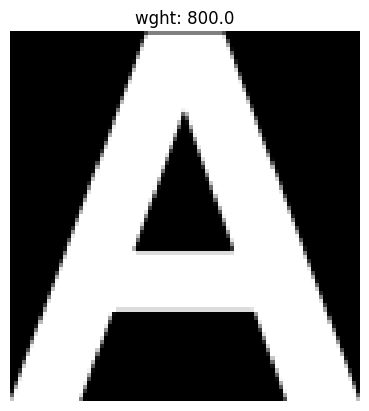

In [28]:
import freetype
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt  # for displaying images, optional

def render_glyph_with_variation(font_path, char, axis_tag="wght", steps=5):
    # Load the font face
    face = freetype.Face(font_path)
    
    # Check if the font is variable by trying to get multiple master information
    try:
        variation_info = face.get_variation_info()
        # axes = variation_info.axes
        # tag = axes[0].tag
        # instances = variation_info.instances
    except freetype.ft_errors.FT_Exception:
        print("This font does not support variable axes.")
        return


    # # Find the desired axis (for simplicity, we assume the axis exists)
    # target_axis = None
    # for axis in variation_info.axes:
    #     # axis.tag is a 4-character code, e.g., 'wght'
    #     if axis == axis_tag:
    #         target_axis = axis
    #         break
    
    # if target_axis is None:
    #     print(f"Axis {axis_tag} not found in this font.")
    #     return

    # # Create a list of values from the minimum to maximum value for the axis
    # values = np.linspace(target_axis.minimum, target_axis.maximum, num=steps)

    images = []
    for instance in variation_info.instances:
        # Set the design coordinate for the axis.
        # If the font has only one variable axis, we pass a single value in a list.
        # print(instance.coords[0])
        face.set_var_design_coords([instance.coords[0]])

        face.set_pixel_sizes(0, 128)  # or whatever pixel height you desire
        
        # Load the character
        face.load_char(char)
        bitmap = face.glyph.bitmap
        
        # Convert the bitmap buffer to a NumPy array.
        # The bitmap buffer is a flat list of pixel intensities.
        width, rows = bitmap.width, bitmap.rows
        # # Create a numpy array from the bitmap buffer
        arr = np.array(bitmap.buffer, dtype=np.uint8).reshape(rows, width)
        
        # # Create a Pillow image from the array
        img = Image.fromarray(arr, mode='L')
        images.append((instance.coords[0], img))
    
    return images

# Example usage:
font_path = "/Users/ethan.smith/fonts/newfonts/42dotSans[wght].ttf"  # Replace with the path to your variable font file
char_to_render = "A"
variation_images = render_glyph_with_variation(font_path, char_to_render, axis_tag="wght", steps=5)

if variation_images:
    # Save and/or display the rendered images.
    for value, img in variation_images:
        filename = f"glyph_{char_to_render}_wght_{int(value)}.png"
        print(filename)
        img.save(filename)
        print(f"Saved image with {value=} as {filename}.")
        
        # Optionally display the image using matplotlib
        plt.figure()
        plt.imshow(img, cmap='gray')
        plt.title(f"wght: {value}")
        plt.axis('off')
    plt.show()


In [2]:
freetype.__version__

AttributeError: module 'freetype' has no attribute '__version__'